# Лекция 6: Image Segmentation

**План лекции:**

1. Постановка задачи
3. Метрики
4. Функции потерь
5. Семантическая сегментация
6. Инстанс сегментация
7. Трансформеры в сегментации
8. SAM


In [39]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision import models
import requests
import torch.nn.functional as F
import torch.nn as nn
from torch import Tensor

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from transformers import Mask2FormerImageProcessor, Mask2FormerForUniversalSegmentation
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

%matplotlib inline

## 1. Постановка задачи


### Что такое сегментация?

Сегментация — это задача **пиксельного предсказания**, где модель определяет:

> к какому классу или объекту принадлежит каждый пиксель изображения

Отличие от классификации:

- классификация:  
  $$
  image \rightarrow label
  $$

- сегментация:  
  $$
  image \rightarrow H \times W \text{ карта меток}
  $$

---

### Типы сегментации
![segmentation](assets/segmentation-1.png)


### Semantic Segmentation

Каждый пиксель принадлежит классу, объекты не разделяются.

$$
image \rightarrow \text{class mask}
$$

```
out = Tensor(C, H, W)
```

---

### Instance Segmentation

Каждый объект — отдельная маска, даже если класс одинаковый.

$$
image \rightarrow \{mask_1, mask_2, ..., mask_n\}
$$

```
out = {  
        masks: Tensor(N, H, W), 
        boxes: Tensor(N, 4),  
        classes: Tensor(N),  
        scores: Tensor(N)  
}  
```

---

### Panoptic Segmentation

![segmentation_types](assets/segmentation-2.jpg)

Комбинация:

- stuff-классы → semantic
- thing-классы → instance

**Две головы:**

- Semantic head:
    - semantic_logits: (C, H, W)
    - semantic_probs:  (C, H, W)
- Instance head:
    - instance_logits / embeddings / queries

```
out = {  
        class_map: Tensor(H, W),  
        instance_map: Tensor(H, W)  
}  

class_map[y,x] = class
id_map[y,x]    = instance_id
```



`label_ids_to_fuse` unset. No instance will be fused.


Text(0.5, 1.0, 'Panoptic (Mask2Former)')

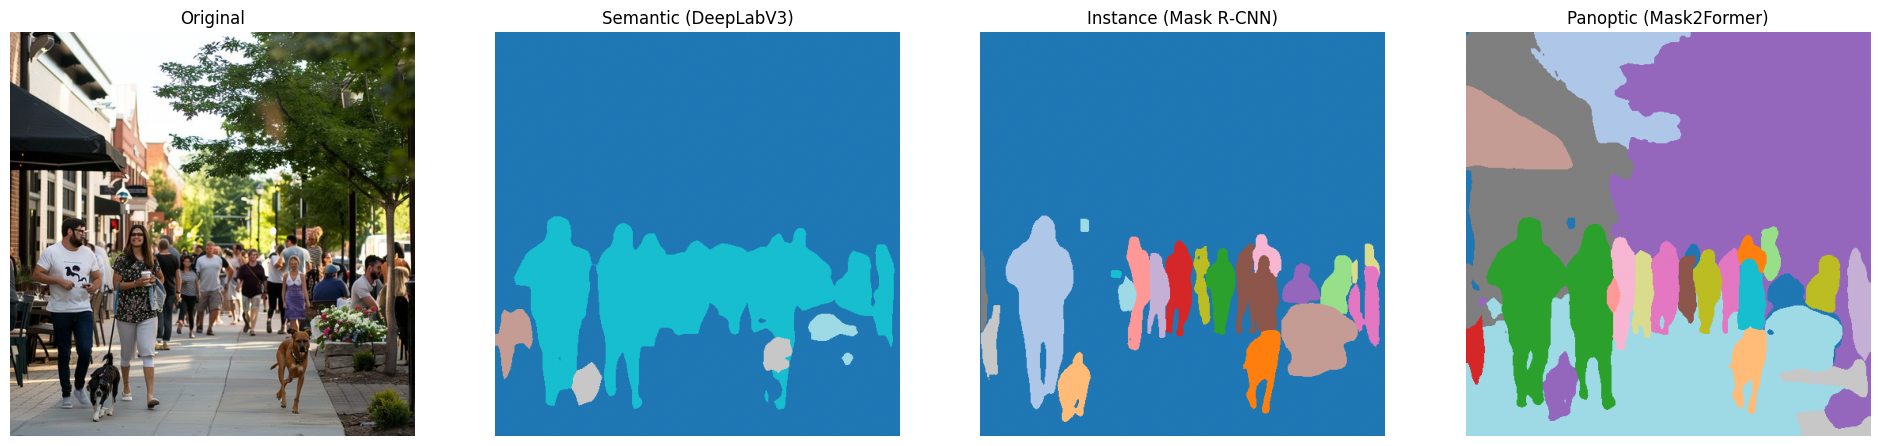

In [4]:
img_pil = Image.open("assets/StockCake-Sidewalk_Dog_Walk-1091895-medium.jpg").convert("RGB")
transform = T.Compose([T.Resize((520, 520)), T.ToTensor()])
x = transform(img_pil).unsqueeze(0)

# Semantic segmentation
semantic_model = torchvision.models.segmentation.deeplabv3_resnet101(
    weights=torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1
).eval()
with torch.no_grad():
    semantic_out = semantic_model(x)["out"]
    semantic_map = semantic_out.argmax(1)[0]


# Instance segmentation
instance_model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
).eval()
with torch.no_grad():
    inst_out = instance_model(x)[0]
    masks = inst_out["masks"][:, 0]
    scores = inst_out["scores"]

    instance_id_map = torch.zeros_like(masks[0], dtype=torch.long)
    idx = 1
    for i in range(len(masks)):
        if scores[i] > 0.7:
            instance_id_map[masks[i] > 0.5] = idx
            idx += 1


# Panoptic segmentation 
processor = AutoImageProcessor.from_pretrained(
    "facebook/mask2former-swin-base-coco-panoptic"
)
panoptic_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-base-coco-panoptic"
)
inputs = processor(images=img_pil, return_tensors="pt")
with torch.no_grad():
    outputs = panoptic_model(**inputs)

# Post-process panoptic output
target_size = [(img_pil.height, img_pil.width)]
panoptic_result = processor.post_process_panoptic_segmentation(
    outputs, target_sizes=target_size
)[0]
panoptic_map = panoptic_result["segmentation"]


# Visualization
fig, axs = plt.subplots(1, 4, figsize=(24,6))

axs[0].imshow(img_pil)
axs[0].axis("off")
axs[0].set_title("Original")

axs[1].imshow(semantic_map.cpu().numpy(), cmap="tab20")
axs[1].axis("off")
axs[1].set_title("Semantic (DeepLabV3)")

axs[2].imshow(instance_id_map.cpu().numpy(), cmap="tab20")
axs[2].axis("off")
axs[2].set_title("Instance (Mask R‑CNN)")

axs[3].imshow(panoptic_map.cpu().numpy(), cmap="tab20")
axs[3].axis("off")
axs[3].set_title("Panoptic (Mask2Former)")

## 2. Метрики сегментации 

### 2.0 Главное отличие от детекции:

- Сегментация оценивает качество на **уровне пикселя**.  
- Детекция оценивает качество на **уровне объекта** (bounding box).

Если представить маску класса как бинарное изображение:  

- 1 — пиксель принадлежит классу  
- 0 — пиксель не принадлежит классу
- Маска предсказания обычно бинаризована по трешходу, но может быть и в виде вероятностей (soft)

$$
\text{mask}_{pred} = (\text{mask}_{probs} > threshold).float()
$$


Тогда **пересечение (intersection)** можно посчитать как поэлементное **умножение** масок:  

$$
\text{Intersection} = \text{mask}_{pred} \cdot \text{mask}_{gt}
$$

А **объединение (union)** — как поэлементную **сумму** масок с вычитанием пересечения:

$$
\text{Union} = \text{mask}_{pred} + \text{mask}_{gt} - \text{mask}_{pred} \cdot \text{mask}_{gt}
$$


### 2.1 Intersection over Union (IoU)

Для каждого класса IoU вычисляется как отношение площади пересечения предсказанных и истинных пикселей к площади их объединения:

$$
\text{IoU} = \frac{Intersection}{Union} = \frac{TP}{TP + FP + FN} = \frac{\sum (\text{mask}_{pred} \cdot \text{mask}_{gt})}{\sum (\text{mask}_{pred} + \text{mask}_{gt} - \text{mask}_{pred} \cdot \text{mask}_{gt})}
$$

где:  
- $TP$ — пиксели, правильно отнесённые к классу (True Positive)  
- $FP$ — пиксели, ошибочно предсказанные как класс (False Positive)  
- $FN$ — пиксели класса, которых модель не обнаружила (False Negative)

Недостатки:
- Чувствителен к маленьким объектам  
  Если объект маленький, даже несколько пикселей ошибки сильно портят IoU.]
- Плохо ведёт себя при очень маленьком пересечении  
  Метрика может быстро падать почти до нуля.]
---

### 2.2 Dice Coefficient (F1-score для сегментации)

$$
\text{Dice} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN} = \frac{2 \sum (\text{mask}_{pred} \cdot \text{mask}_{gt})}{\sum (\text{mask}_{pred}) + \sum (\text{mask}_{gt})}
$$


**Связь с IoU:**

$$
\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}
$$

### 2.3 Pixel Accuracy

Доля правильно классифицированных пикселей:

$$
\text{Pixel Accuracy} = \frac{\text{число правильно классифицированных пикселей}}{\text{общее число пикселей}}
$$

Недостаток: сильно чувствительна к дисбалансу классов (например, если фон занимает 90% изображения, высокая точность может быть достигнута, не распознавая объекты).


In [26]:
def segmentation_stats(
    mask_pred: Tensor,
    mask_gt: Tensor,
    threshold: float = 0.5
) -> tuple[Tensor, Tensor, Tensor]:

    mask_pred_bin = (mask_pred > threshold).float()
    mask_gt = mask_gt.float()

    tp = (mask_pred_bin * mask_gt).sum()
    fp = (mask_pred_bin * (1 - mask_gt)).sum()
    fn = ((1 - mask_pred_bin) * mask_gt).sum()

    return tp, fp, fn


def iou_score(
    mask_pred: Tensor,
    mask_gt: Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7
) -> Tensor:
    tp, fp, fn = segmentation_stats(mask_pred, mask_gt, threshold)
    return tp / (tp + fp + fn + eps)


def dice_score(
    mask_pred: Tensor,
    mask_gt: Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7
) -> Tensor:
    tp, fp, fn = segmentation_stats(mask_pred, mask_gt, threshold)
    return (2 * tp) / (2 * tp + fp + fn + eps)


def pixel_accuracy(
    mask_pred: Tensor,
    mask_gt: Tensor,
    threshold: float = 0.5
) -> Tensor:
    mask_pred_bin = (mask_pred > threshold).float()
    mask_gt = mask_gt.float()

    correct = (mask_pred_bin == mask_gt).sum()
    total = mask_gt.numel()

    return correct.float() / total


mask_gt = torch.randint(0, 2, (256, 256), dtype=torch.float32)
mask_pred = torch.rand((256, 256), dtype=torch.float32)

iou = iou_score(mask_pred, mask_gt)
dice = dice_score(mask_pred, mask_gt)
acc = pixel_accuracy(mask_pred, mask_gt)

print(f"IoU: {iou.item():.4f}")
print(f"Dice: {dice.item():.4f}")
print(f"Pixel Accuracy: {acc.item():.4f}")

IoU: 0.3361
Dice: 0.5031
Pixel Accuracy: 0.5043


## 3. Loss-функции для сегментации изображений

### 1. Per-pixel Loss

В задачах сегментации функции потерь обычно вычисляются **для каждого пикселя независимо**, после чего усредняются по всем пикселям изображения.

---

#### 1.1 Binary Cross-Entropy (BCE)

Используется для **бинарной сегментации**.

$$
\text{BCE} =- \frac{1}{N} \sum_{i=1}^{N} \left[y_i \log(p_i) + (1-y_i)\log(1-p_i) \right]
$$

где:

- $N$ — число пикселей
- $y_i \in {0,1}$ — истинная метка пикселя
- $p_i \in [0,1]$ — предсказанная вероятность класса

На практике в большинстве библиотек используется **BCEWithLogitsLoss**, где модель выдаёт **logits**, а sigmoid применяется внутри функции потерь.

---

##### Многоклассовая сегментация (Cross-Entropy)

Для задач с $K$ классами используется **pixel-wise Cross-Entropy**:

$$
\text{CE} =- \frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{K} y_{i,c}\log(p_{i,c})
$$

где:

- $K$ — число классов
- $y_{i,c}$ — one-hot метка класса
- $p_{i,c}$ — вероятность класса

На практике в segmentation обычно используется **целочисленная маска классов**, а не one-hot представление.

---

#### 1.2 Focal Loss

Focal Loss — модификация BCE, предназначенная для задач с **сильным дисбалансом классов**.

$$
\text{FL}(p_t) = - \alpha (1-p_t)^\gamma \log(p_t)
$$

где

$$
p_t =
\begin{cases}
p_i, & y_i = 1 \\
1 - p_i, & y_i = 0
\end{cases}
$$

параметры:

- $\alpha \in [0,1]$ — балансировка классов
- $\gamma \ge 0$ — коэффициент фокусировки

**Эффект:** хорошо классифицированные пиксели дают меньший вклад в loss, что заставляет модель фокусироваться на сложных примерах.

---

#### 1.3 Soft Cross-Entropy

Если разметка является **вероятностной**, а не дискретной:

$$
\quad \sum_{c=1}^{K} y_{i,c} = 1
$$

используется Soft Cross-Entropy:

$$
\text{SoftCE} = - \frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{K} y_{i,c}\log(p_{i,c})
$$

Такая постановка позволяет учитывать **мягкую разметку**.

Применяется в:

- semi-supervised learning
- knowledge distillation
- label smoothing

___

### 2. Metric-based Loss (Dice и IoU)

Переход от метрики к Loss:

$$
\text{Loss} = 1 - \text{Метрика}
$$

- Dice Loss: $1 - \text{Dice}$  
- IoU Loss: $1 - \text{IoU}$  

Высокая метрика → низкий Loss, низкая метрика → высокий Loss  

In [27]:
def binary_cross_entropy(p: torch.Tensor, y: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = torch.clamp(p, eps, 1 - eps)
    loss = -(y * torch.log(p) + (1 - y) * torch.log(1 - p))
    return loss.mean()


def cross_entropy_multiclass(p: torch.Tensor, y: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = torch.clamp(p, eps, 1 - eps)
    # предполагаем, что y — one-hot
    loss = -(y * torch.log(p)).sum(dim=-1)
    return loss.mean()


def focal_loss_binary(
    p: torch.Tensor,
    y: torch.Tensor,
    alpha: float = 0.25,
    gamma: float = 2.0,
    eps: float = 1e-7
) -> torch.Tensor:
    p = torch.clamp(p, eps, 1 - eps)
    pt = torch.where(y == 1, p, 1 - p)
    loss = -alpha * (1 - pt) ** gamma * torch.log(pt)
    return loss.mean()


mask_gt = torch.randint(0, 2, (256, 256), dtype=torch.float32)
mask_pred = torch.rand((256, 256), dtype=torch.float32)

bce = binary_cross_entropy(mask_pred, mask_gt)
fl = focal_loss_binary(mask_pred, mask_gt)

print(f"Binary CE: {bce.item():.4f}")
print(f"Focal Loss: {fl.item():.4f}")

Binary CE: 1.0006
Focal Loss: 0.1530


### 3. Продвинутые Loss-функции

#### 3.1 Tversky Loss

Tversky Loss позволяет управлять **FP и FN**:

$$
\text{Tversky} = \frac{TP}{TP + \alpha \cdot FP + \beta \cdot FN}, \quad
\text{Tversky Loss} = 1 - \text{Tversky}
$$

- $\alpha$ — штраф за FP  
- $\beta$ — штраф за FN  
- Если $\alpha = \beta = 0.5$ → Tversky = Dice  


#### 3.2 Lovasz-Softmax Loss 

Lovasz-Softmax Loss — дифференцируемая аппроксимация **IoU**, оптимизируемая через градиенты ошибок пикселей

$$
\mathcal{L}_{\text{Lovasz}} \approx \sum_i w_i \cdot (1 - \text{IoU}_i)
$$

- $w_i$ — вес, отражающий вклад ошибки пикселя в IoU  
- Для многоклассовой сегментации усредняется по классам:

**1. Определяем ошибки по пикселям**
Для бинарной маски:

$$
m_i = 1 - p_i \cdot (2 y_i - 1)
$$

- $p_i \in [0,1]$ — предсказанная вероятность  
- $y_i \in \{0,1\}$ — истинная метка  
- $m_i$ — ошибка каждого пикселя  

> $m_i$ = 0 для идеально предсказанного пикселя и растёт для ошибок.

**2. Сортировка ошибок**
Пиксели сортируются по убыванию ошибки:

$$
m_{(1)} \ge m_{(2)} \ge ... \ge m_{(N)}
$$

- $(i)$ — индекс после сортировки  
- Сортировка нужна, чтобы вычислить **градиент изменения IoU**.


**3. Градиент IoU**
Для отсортированных ошибок градиент:

$$
\Delta_i = \text{IoU}(i) - \text{IoU}(i-1)
$$

- $\text{IoU}(i)$ — IoU при исправлении первых $i$ ошибок  
- $\Delta_i$ показывает вклад $i$-го пикселя в улучшение IoU  

**4. Lovasz-Hinge Loss (бинарный случай)**

$$
\mathcal{L}_{\text{Lovasz}} = \sum_{i=1}^{N} m_{(i)} \cdot \Delta_i
$$

- Ошибки пикселей, которые сильнее влияют на IoU, получают больший вес  
- Loss = 0, если предсказания идеальны


**5. Многоклассовая версия**

Для $K$ классов усредняем:

$$
\mathcal{L}_{\text{Lovasz-Softmax}} = \frac{1}{K} \sum_{c=1}^{K} \mathcal{L}_{\text{Lovasz}}^{(c)}
$$


**Особенности:**

- Минимизирует ошибки, влияющие на IoU  
- Дифференцируемо для градиентного спуска  
- Особенно полезно для **мелких объектов и сложных границ**  

**Упрощение вычеслений:**

После сортировки ошибок:

```python
errors_sorted, perm = torch.sort(errors, descending=True)
target_sorted = target[perm]
```

вычисляется градиент:

```
grad = target_sorted.float().cumsum(0) / target_sorted.sum()
```
$$
\text{grad}_i =
\frac{\sum_{j=1}^{i} y_{(j)}}{\sum_{j=1}^{N} y_j} = \frac{TP_i}{TP+FN}
$$

In [28]:
def compute_confusion(pred: Tensor, target: Tensor) -> tuple[Tensor, Tensor, Tensor]:

    tp = torch.sum(pred * target)
    fp = torch.sum(pred * (1.0 - target))
    fn = torch.sum((1.0 - pred) * target)
    return tp, fp, fn


def tversky_loss(
    pred: Tensor,
    target: Tensor,
    alpha: float = 0.3,
    beta: float = 0.7,
    eps: float = 1e-7,
) -> Tensor:

    tp, fp, fn = compute_confusion(pred, target)

    tversky = tp / (tp + alpha * fp + beta * fn + eps)

    return 1.0 - tversky


def lovasz_hinge_loss(pred: Tensor, target: Tensor, eps: float = 1e-7,) -> Tensor:

    pred = pred.view(-1)
    target = target.view(-1)

    signs = 2.0 * target - 1.0

    errors = 1.0 - pred * signs
    errors = torch.clamp(errors, min=0.0)

    errors_sorted, perm = torch.sort(errors, descending=True)
    target_sorted = target[perm]

    grad = target_sorted.float().cumsum(0) / target_sorted.sum().clamp(min=eps)

    loss = torch.sum(errors_sorted * grad) / target_sorted.numel()

    return loss


tversky = tversky_loss(mask_pred, mask_gt)
lovasz = lovasz_hinge_loss(mask_pred, mask_gt)

print(f"Tversky: {tversky.item():.4f}")
print(f"Lovasz: {lovasz.item():.4f}")

Tversky: 0.4989
Lovasz: 0.0828


# 3. Семантическая сегментация: архитектуры и улучшения

Семантическая сегментация — это задача классификации каждого пикселя изображения, где каждому пикселю присваивается класс.  

Основные современные подходы основаны на **encoder-decoder архитектурах**, улучшенных различными методами для повышения качества сегментации и сохранения мелких деталей.

## 3.1 U-Net (Ronneberger et al., 2015)

**U-Net** — классическая архитектура для семантической сегментации  

### Архитектура

- **Encoder (сжимающая часть)**: последовательность свёрточных блоков + MaxPooling  
- **Decoder (расширяющая часть)**: Upsampling + свёртки  
- **Skip-connections**: соединяют соответствующие уровни encoder и decoder для сохранения пространственной информации

### Схема:
Input -> [Encoder] -> Bottleneck -> [Decoder] -> Output
| ^
+---- skip connections -----+


- Сохраняет **детали мелких объектов**  
- Подходит для малых датасетов благодаря эффективному обучению


![unet_nn](assets/u-net-architecture.png)

**Идея:** объединить **глобальный контекст** (что изображено) и **точную локализацию** (где именно находится объект).  
Для этого используется **encoder–decoder архитектура** со **skip connections**.

Архитектура состоит из трёх частей:

Encoder → Bottleneck → Decoder

---

### Encoder (downsampling path)

Encoder извлекает признаки и постепенно уменьшает spatial-размер изображения.

Обычно один уровень encoder состоит из:

`Conv 3×3 → ReLU → Conv 3×3 → ReLU → MaxPool`

Формально:

$$
x_l = F_l(x_{l-1})
$$

где $F_l(\cdot)$ — **ConvBlock**:

$$
F_l(x) = ReLU(Conv_{3×3}(ReLU(Conv_{3×3}(x))))
$$

После каждого блока выполняется downsampling:

$$
x_{l}^{down} = Pool(x_l)
$$

Размерность меняется примерно так:


H×W×3  
↓  
H×W×64  
↓  
H/2×W/2×128  
↓  
H/4×W/4×256  
↓  
H/8×W/8×512  


Encoder учится **понимать содержимое изображения**.

---

#### Bottleneck

Самая глубокая часть сети.


Conv 3×3 → ReLU → Conv 3×3 → ReLU


Обычно имеет максимальное число каналов:


512 → 1024


Задача bottleneck — агрегировать **глобальный контекст изображения**.

---

#### Decoder (upsampling path)

Decoder постепенно восстанавливает исходное разрешение.

Один уровень decoder:

`Upsample → concat(skip) → Conv 3×3 → ReLU → Conv 3×3 → ReLU`

Формально:

1. Upsampling

$$
x^{up}_l = Up(x_{l+1})
$$

2. Skip connection (конкатенация признаков encoder)

$$
x_l^{cat} = [x_l^{enc}, x_l^{up}]
$$

где `[ , ]` — **конкатенация по каналам**.

3. Conv block

$$
x_l^{dec} = F_l(x_l^{cat})
$$

---

#### Skip Connections

Ключевая идея U-Net.

Соединяются **feature maps encoder и decoder одинакового масштаба**.

$$
x_l^{dec} = F_l([x_l^{enc}, Up(x_{l+1})])
$$

Это позволяет:

- сохранить **точные границы объектов**
- компенсировать потерю информации из-за pooling
- улучшить локализацию сегментации

---

#### Финальный слой

Последний слой сети:


Conv 1×1


Он переводит признаки в **классы сегментации**.

Для $C$ классов:

$$
y = Conv_{1×1}(x)
$$

Размер выхода:


H × W × C


После этого обычно применяется **Softmax / Sigmoid**, чтобы получить вероятности классов для каждого пикселя.

---

#### Плюсы

- Хорошая **локализация объектов**
- Простая и стабильная архитектура
- Отлично работает даже на **небольших датасетах**
- Очень популярна в **medical imaging**

---

#### Минусы

- Ограниченный **receptive field**
- Не очень хорошо захватывает **мульти-масштабный контекст**
- Skip connections соединяют только одинаковые уровни

Поэтому позже появились улучшения:

- **FPN / PAN** — улучшенная мульти-масштабность
- **U-Net++** — nested skip connections
- **U²-Net** — вложенные U-Net блоки
- **DeepLab v3** — atrous convolution и ASPP

In [36]:
def count_trainable_params(model: torch.nn.Module) -> int:
    """Возвращает количество обучаемых параметров в модели"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class ConvBlock(nn.Module):
    """Conv 3x3 -> ReLU -> Conv 3x3 -> ReLU"""

    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNet(nn.Module):
    """Basic U-Net"""

    def __init__(self, in_channels: int, num_classes: int) -> None:
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)
        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        # Final conv
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        b = self.bottleneck(self.pool(e4))
        # Decoder
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final_conv(d1)

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.randn(2, 3, 256, 256).to(device)

model_unet = UNet(3, 2).to(device)
y_unet = model_unet(x)
print("U-Net output shape:", y_unet.shape)
print(f"U-Net trainable params: {count_trainable_params(model_unet):,}")


U-Net output shape: torch.Size([2, 2, 256, 256])
U-Net trainable params: 31,031,810


## 3.2 Feature Pyramid Network (FPN, 2017, Lin et al.)

**Идея:** строить пирамиду признаков разных масштабов и использовать их одновременно.

![fpn](assets/fpn.png)

#### Проблема обычных CNN

В CNN признаки имеют разный уровень абстракции:

```
Layer 1 → high resolution, low semantics
Layer 2
Layer 3
Layer 4 → low resolution, high semantics
```

То есть:

- ранние слои → **детали**
- поздние слои → **семантика**

Но обычные CNN используют **только последний уровень**.

---

#### 4. Bottom-up pathway (encoder)

Encoder извлекает признаки разных масштабов:


C2 → C3 → C4 → C5


где

- $C_i$ — feature maps encoder на уровне $i$.

Типичные размеры:

| уровень | размер |
|---|---|
| $C_2$ | $H/4 \times W/4$ |
| $C_3$ | $H/8 \times W/8$ |
| $C_4$ | $H/16 \times W/16$ |
| $C_5$ | $H/32 \times W/32$ |

Глубокие уровни имеют:

- больше **семантики**
- меньше **пространственного разрешения**.

---

#### 5. Top-down pathway

FPN добавляет **top-down pathway**, который распространяет семантику от глубоких уровней к мелким.

Сначала строится верхний уровень пирамиды:

$$
P_5 = Conv_{1\times1}(C_5)
$$

Далее уровни формируются рекурсивно:

$$
P_l = Conv_{1\times1}(C_l) + Up(P_{l+1})
$$

где

- $Up(\cdot)$ — upsampling
- $+$ — поэлементное сложение.

---

#### 6. Lateral connections

Связи между encoder и pyramid называются **lateral connections**.

Обычно применяется дополнительная свертка для сглаживания:

$$
P_l = Conv_{3\times3}(Conv_{1\times1}(C_l) + Up(P_{l+1}))
$$

Здесь

- **1×1 Conv** выравнивает число каналов
- **Upsample** увеличивает разрешение
- **3×3 Conv** уменьшает aliasing после сложения.

---

#### 7. Интуитивная интерпретация

Каждый уровень пирамиды объединяет

- **детали** из encoder
- **семантику** из более глубоких слоев.

Интуитивно:

$$
P_l = \text{detail}(C_l) + \text{semantics}(P_{l+1})
$$

То есть каждый уровень содержит **и локальные детали, и глобальный контекст**.

---

#### 8. Сравнение U-Net и FPN

**Decoder U-Net**


Upsample
↓
Concat(skip)
↓
Conv block


Формально

$$
x_l^{dec} = F([x_l^{enc}, Up(x_{l+1}^{dec})])
$$

---

**Fusion в FPN**


Upsample
↓
Sum(skip)
↓
Conv


Формально

$$
P_l = Conv(C_l + Up(P_{l+1}))
$$

---

**Главное отличие**

| U-Net | FPN |
|---|---|
| concat | sum |
| отдельный decoder | pyramid features |
| один выход | multi-scale outputs |

---

#### 9. FPN для сегментации

В задачах сегментации FPN можно использовать как **decoder**.

Архитектура:


**Backbone (ResNet)**  

C2 C3 C4 C5  
↓ ↓ ↓ ↓  

**FPN**  

P2 P3 P4 P5  
↓  
upsample to same size  
↓  
concat  
↓  
Conv  
↓  
Segmentation mask  


Формально финальная сегментация может быть получена как

$$
F = Concat(P_2, Up(P_3), Up(P_4), Up(P_5))
$$

После этого

$$
y = Conv_{1\times1}(F)
$$

где $y$ — карта сегментации.


---

#### 10. Преимущества FPN

**Multi-scale representation**

Сеть явно использует **несколько масштабов признаков**.

**Более эффективное объединение признаков**

Семантика распространяется **по всей пирамиде**, а не только локально.

**Меньше параметров**

Сложение не увеличивает число каналов:


256 + 256 → 256


в отличие от concat.

---

#### 11. Развитие идей FPN

После FPN появились архитектуры, улучшающие обмен информацией между масштабами:

- **PAN (Path Aggregation Network)** — добавляет bottom-up путь
- **BiFPN** — обучаемые веса для fusion разных масштабов
- **U-Net++** — улучшенные skip connections

Все они развивают одну идею:

эффективное объединение **multi-scale признаков**.

In [42]:
from typing import Literal

class FPN(nn.Module):
    def __init__(
        self,
        num_classes: int = 1,
        backbone_name: Literal['resnet18', 'resnet34', "resnet50", "resnet101"] = 'resnet34',
        pretrained: bool = False
    ) -> None:
        super().__init__()

        # -------------------------------
        # Загружаем backbone
        # -------------------------------
        if pretrained:
            weights = getattr(models, f"{backbone_name.capitalize()}_Weights").DEFAULT
        else:
            weights = None
        backbone = getattr(models, backbone_name)(weights=weights)
        self.in_channels = 256  # для FPN lateral conv, можно менять по backbone

        # Основные слои энкодера
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        # Слои для фич на разных уровнях
        self.layer1 = backbone.layer1  # c2
        self.layer2 = backbone.layer2  # c3
        self.layer3 = backbone.layer3  # c4
        self.layer4 = backbone.layer4  # c5

        # -------------------------------
        # lateral 1x1 conv для FPN
        # -------------------------------
        # Определяем число каналов для каждого уровня в зависимости от backbone
        if backbone_name in ['resnet18', 'resnet34']:
            channels = [64, 128, 256, 512]
        else:  # resnet50, resnet101
            channels = [256, 512, 1024, 2048]

        self.lateral4 = nn.Conv2d(channels[3], 256, 1)
        self.lateral3 = nn.Conv2d(channels[2], 256, 1)
        self.lateral2 = nn.Conv2d(channels[1], 256, 1)
        self.lateral1 = nn.Conv2d(channels[0], 256, 1)

        # smooth conv после суммирования
        self.smooth4 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth3 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth2 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth1 = nn.Conv2d(256, 256, 3, padding=1)

        # финальная свёртка после конкатенации
        self.out_conv = nn.Conv2d(256*4, num_classes, 1)

    def forward(self, x):
        # -------------------------------
        # Энкодер
        # -------------------------------
        c1 = self.relu(self.bn1(self.conv1(x)))
        c1p = self.maxpool(c1)
        c2 = self.layer1(c1p)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)

        # -------------------------------
        # Top-down FPN
        # -------------------------------
        p5 = self.smooth4(self.lateral4(c5))
        p4 = self.smooth3(self.lateral3(c4) + F.interpolate(p5, size=c4.shape[2:], mode='nearest'))
        p3 = self.smooth2(self.lateral2(c3) + F.interpolate(p4, size=c3.shape[2:], mode='nearest'))
        p2 = self.smooth1(self.lateral1(c2) + F.interpolate(p3, size=c2.shape[2:], mode='nearest'))

        # -------------------------------
        # Upsample все уровни до входа и конкатенируем
        # -------------------------------
        p2_up = F.interpolate(p2, size=x.shape[2:], mode='bilinear', align_corners=False)
        p3_up = F.interpolate(p3, size=x.shape[2:], mode='bilinear', align_corners=False)
        p4_up = F.interpolate(p4, size=x.shape[2:], mode='bilinear', align_corners=False)
        p5_up = F.interpolate(p5, size=x.shape[2:], mode='bilinear', align_corners=False)

        out = torch.cat([p2_up, p3_up, p4_up, p5_up], dim=1)
        out = self.out_conv(out)
        return out



model_fpn = FPN(num_classes=1, backbone_name='resnet34', pretrained=False)
x = torch.rand(1, 3, 256, 256)
y_fpn = model_fpn(x)
print("FPN output shape:", y_fpn.shape)
print(f"FPN trainable params: {count_trainable_params(model_fpn):,}")

FPN output shape: torch.Size([1, 1, 256, 256])
FPN trainable params: 23,892,801


## 3.3 Path Aggregation Network (PAN, 2018, Liu et al.)

#### Идея Path Aggregation Network

После FPN информация распространяется:  

C5 → C4 → C3 → C2  

Но обратного движения нет.  

То есть детали из C2 плохо влияют на глубокие уровни.  

Схема FPN:  
`
Bottom-up:  C2 → C3 → C4 → C5 
`

`
Top-down:   P5 → P4 → P3 → P2  
`  
Но нет пути:  
`
P2 → P3 → P4 → P5
`

**PAN добавляет ещё один путь:**
`
P2 → N3 → N4 → N5
`
То есть:

детали ↑
семантика ↓

Теперь признаки обмениваются информацией в **обе стороны**.

---

#### 3. Архитектура PAN

![pan](assets/pan.png)

Архитектура состоит из двух частей:

- **Feature Pyramid (как в FPN)**  
- **Path Aggregation (новый bottom-up путь)**

---

#### Шаг 1 — построение FPN

Encoder извлекает признаки:


C2 → C3 → C4 → C5


Строим пирамиду:


P2
P3
P4
P5


формула:

$$
P_l = Conv_{3×3}(Conv_{1×1}(C_l) + Up(P_{l+1}))
$$

---

#### Шаг 2 — Path Aggregation (новый путь)

PAN добавляет **обратное распространение признаков**.

Схема:


P2 → downsample → N3  
N3 + P3 → conv → N3  


N3 → downsample → N4  
N4 + P4 → conv → N4  


N4 → downsample → N5  
N5 + P5 → conv → N5  


Формально:

$$
N_l = Conv(P_l + Down(N_{l-1}))
$$

где

- $Down(\cdot)$ — downsampling (обычно stride=2 conv)
- $+$ — поэлементное сложение

---

#### 4. Полная схема PAN


Encoder

C2 → C3 → C4 → C5

Top-down (FPN)

P2 ← P3 ← P4 ← P5

Bottom-up (PAN)

P2 → N3 → N4 → N5


В итоге получаем **улучшенную пирамиду признаков**:


N2 N3 N4 N5


---

#### 5. Интуитивная интерпретация

FPN распространяет **семантику сверху вниз**:


semantics ↓


PAN добавляет распространение **деталей снизу вверх**:


details ↑


Таким образом:

| путь | что передаёт |
|-----|-----|
| Top-down | семантика |
| Bottom-up | локализация |

---

#### 7. Использование PAN в сегментации

В сегментации архитектура может выглядеть так:


- Backbone  
  C2 C3 C4 C5
- FPN  
  P2 P3 P4 P5
- PAN  
  N2 N3 N4 N5

Финальный feature map:

$$
F = Concat(N_2, Up(N_3), Up(N_4), Up(N_5))
$$

После чего строится маска:

$$
y = Conv_{1×1}(F)
$$

---

#### 8. Преимущества PAN

**Более короткий путь распространения информации**

Глубокие слои получают детали быстрее.

**Улучшенная локализация**

Особенно для:

- мелких объектов
- тонких структур.

**Более богатые multi-scale признаки**

Каждый уровень содержит:

- семантику
- детали
- контекст

---

#### 9. Связь с современными архитектурами

Идея PAN легла в основу многих архитектур:

- **PANet** (Path Aggregation Network)
- **YOLOv4 / YOLOv5 PAN neck**
- **BiFPN (EfficientDet)**

Все они используют **двусторонний обмен multi-scale признаками**.

---

#### 10. Главное отличие U-Net, FPN и PAN

| архитектура | идея |
|---|---|
| U-Net | encoder–decoder + skip connections |
| FPN | multi-scale pyramid + top-down fusion |
| PAN | bidirectional multi-scale fusion |

Главная идея PAN:

$$
\text{features} = f(\text{top-down semantics}, \text{bottom-up details})
$$

То есть объединение **семантики и локализации на всех уровнях сети**.

In [43]:
class PAN(nn.Module):
    def __init__(
        self,
        num_classes: int = 1,
        backbone_name: str = 'resnet34',
        pretrained: bool = False
    ):
        super().__init__()

        # Backbone
        if pretrained:
            weights = getattr(models, f"{backbone_name.capitalize()}_Weights").DEFAULT
        else:
            weights = None

        backbone = getattr(models, backbone_name)(weights=weights)

        # Этапы энкодера
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1  # c2
        self.layer2 = backbone.layer2  # c3
        self.layer3 = backbone.layer3  # c4
        self.layer4 = backbone.layer4  # c5

        # lateral conv (1x1) для всех уровней
        if backbone_name in ['resnet18', 'resnet34']:
            channels = [64, 128, 256, 512]
        else:  # resnet50/101
            channels = [256, 512, 1024, 2048]

        self.lateral4 = nn.Conv2d(channels[3], 256, 1)
        self.lateral3 = nn.Conv2d(channels[2], 256, 1)
        self.lateral2 = nn.Conv2d(channels[1], 256, 1)
        self.lateral1 = nn.Conv2d(channels[0], 256, 1)

        # smooth conv после суммирования (top-down)
        self.smooth4 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth3 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth2 = nn.Conv2d(256, 256, 3, padding=1)
        self.smooth1 = nn.Conv2d(256, 256, 3, padding=1)

        # bottom-up пути
        self.down3 = nn.Conv2d(256, 256, 3, stride=2, padding=1)
        self.down4 = nn.Conv2d(256, 256, 3, stride=2, padding=1)
        self.down5 = nn.Conv2d(256, 256, 3, stride=2, padding=1)

        # финальная свёртка после конкатенации
        self.out_conv = nn.Conv2d(256*4, num_classes, 1)

    def forward(self, x):
        # -------------------------------
        # Энкодер
        # -------------------------------
        c1 = self.relu(self.bn1(self.conv1(x)))
        c1p = self.maxpool(c1)
        c2 = self.layer1(c1p)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)

        # -------------------------------
        # Top-down путь (FPN)
        # -------------------------------
        p5 = self.smooth4(self.lateral4(c5))
        p4 = self.smooth3(self.lateral3(c4) + F.interpolate(p5, size=c4.shape[2:], mode='nearest'))
        p3 = self.smooth2(self.lateral2(c3) + F.interpolate(p4, size=c3.shape[2:], mode='nearest'))
        p2 = self.smooth1(self.lateral1(c2) + F.interpolate(p3, size=c2.shape[2:], mode='nearest'))

        # -------------------------------
        # Bottom-up путь (PAN)
        # -------------------------------
        p3_pan = self.down3(p2) + p3
        p4_pan = self.down4(p3_pan) + p4
        p5_pan = self.down5(p4_pan) + p5

        # -------------------------------
        # Upsample все уровни до входа и конкатенируем
        # -------------------------------
        p2_up = F.interpolate(p2, size=x.shape[2:], mode='bilinear', align_corners=False)
        p3_up = F.interpolate(p3_pan, size=x.shape[2:], mode='bilinear', align_corners=False)
        p4_up = F.interpolate(p4_pan, size=x.shape[2:], mode='bilinear', align_corners=False)
        p5_up = F.interpolate(p5_pan, size=x.shape[2:], mode='bilinear', align_corners=False)

        out = torch.cat([p2_up, p3_up, p4_up, p5_up], dim=1)
        out = self.out_conv(out)
        return out


model_pan = PAN(num_classes=1, backbone_name='resnet34', pretrained=False)
x = torch.rand(1, 3, 256, 256)
y_pan = model_pan(x)
print("PAN output shape:", y_pan.shape)
print(f"PAN trainable params: {count_trainable_params(model_pan):,}")

PAN output shape: torch.Size([1, 1, 256, 256])
PAN trainable params: 25,663,041


#### Ограничения классического U-Net

Главная проблема — **semantic gap**.

Encoder и decoder работают на разных уровнях абстракции.

| encoder | decoder |
|---|---|
| низкоуровневые признаки | высокоуровневая семантика |
| текстуры | объекты |

То есть skip connection объединяет **очень разные типы признаков**.

## 3.4 U-Net++ (2018, Zhou et al.)

U-Net++ уменьшает **semantic gap** между encoder и decoder.

Вместо одного skip connection используется **цепочка промежуточных сверточных блоков**.

В результате архитектура становится **nested (вложенной)**.

![unet_++](assets/unet++.png)

---

#### Архитектура

В обычном U-Net:


$encoder_l$ ─────────→ $decoder_l$


В U-Net++:


$encoder_l$ → conv → conv → conv → $decoder_l$


То есть skip connection превращается в **маленькую сеть**.

Архитектура приобретает форму **решётки (grid)**.

---

#### Обозначения

В U-Net++ сеть организована как сетка:
![unet_++](assets/unet++_2.jpg)

- **Столбцы** → уровень декодера (глубина восстановления/upsampling)
- **Строки** → уровень энкодера (размер признаков / downsampling)

$$
X_{i,j} \quad\text{где}\quad 
i = \text{номер уровня энкодера (строка)}, \quad 
j = \text{глубина декодера (столбец)}
$$

То есть:

- $X_{0,0}$ — самый верхний узел на первом уровне энкодера (исходное изображение → первый conv блок)
- $X_{1,0}$ — второй уровень энкодера, первый узел
- $X_{0,1}$— первый уровень энкодера, первый узел декодера (после апсемплинга)
- $X_{0,2}$ — первый уровень энкодера, второй узел декодера и так далее

Пример структуры:

$$
X_{0,0} X_{0,1} X_{0,2} X_{0,3}
$$
$$
X_{1,0} X_{1,1} X_{1,2}
$$
$$
X_{2,0} X_{2,1}
$$
$$
X_{3,0}
$$


---

#### Формула вычисления

Каждый узел объединяет

- предыдущие признаки этого уровня
- upsampled признаки более глубокого уровня

$$
X_{i,j} =
Conv\left(
Concat(
X_{i,0}, X_{i,1}, \dots, X_{i,j-1}, Up(X_{i+1,j-1})
)
\right)
$$

Таким образом признаки **постепенно уточняются**.

---

#### Deep Supervision

U-Net++ использует **deep supervision**.

Предсказания делаются на нескольких уровнях decoder:


$X_{0,1}$ → mask1  
$X_{0,2}$  → mask2  
$X_{0,3}$  → mask3  


Общий loss:

$$
L = \sum_{k=1}^{K} w_k L_k
$$

где

- $L_k$ — loss на k-м уровне
- $w_k$ — веса

Преимущества:

- более стабильное обучение
- лучшее распространение градиентов

---

####  Как делается предсказание на этапе inference

Есть два подхода:

1. **Использовать только последний уровень** ($X_{0,K}$)
    - На практике часто берут самое «глубокое» предсказание, потому что оно интегрирует всю информацию.
    - Остальные промежуточные выходы нужны только для **обучения** (deep supervision), чтобы улучшить градиентный поток.
2. **Агрегировать все уровни**
    - Можно усреднять предсказания всех уровней:
        
        $\hat{Y} = \sum_{k=1}^{K} \alpha_k \hat{Y}_k$
        
    - $\alpha_k$ — веса для агрегации (обычно равные или пропорциональные wkw_kwk).
    - Этот подход иногда улучшает точность, особенно если есть шумные сегментации.

#### Преимущества U-Net++

- уменьшает **semantic gap**
- более плавное объединение признаков
- улучшает segmentation accuracy

---

## 3.5 U²-Net (2020, Qin et al.)

![u2net](assets/u2net.png)

#### Основная идея

U²-Net означает

$$
U^2 = U\text{-Net внутри }U\text{-Net}
$$

То есть каждый блок сети — **маленький U-Net**.

---

#### Residual U-block (RSU)

Основной строительный блок — **RSU (Residual U-block)**.

Схема блока:


input  
↓  
conv  
↓  
mini U-Net  
↓  
residual connection  
↓  
output  


---

####  Архитектура RSU

Внутри блока есть собственный encoder-decoder:


conv  
↓  
downsample  
↓  
downsample  
↓  
bottleneck  
↓  
upsample  
↓  
upsample  


Таким образом один блок уже извлекает **multi-scale признаки**.

---

####  Residual формулировка

RSU использует residual связь:

$$
y = x + F(x)
$$

где

- $x$ — вход
- $F(x)$ — mini U-Net

Это облегчает обучение глубокой сети.

---

#### Архитектура всей U²-Net

Глобальная структура остаётся похожей на U-Net:


Encoder  
↓  
Bottleneck  
↓  
Decoder  


Но каждый уровень состоит из **RSU блоков**.

Пример encoder:


RSU7  
↓  
RSU6  
↓  
RSU5  
↓  
RSU4  


Число показывает **глубину mini U-Net внутри блока**.

---

#### Multi-scale обработка

В обычной CNN:


conv → conv → conv


В U²-Net:


mini U-Net внутри блока


Это позволяет извлекать **multi-scale признаки локально**.

---

####  Deep Supervision

U²-Net также использует **side outputs**.


decoder1 → mask1  
decoder2 → mask2  
decoder3 → mask3  


Итоговая маска получается объединением:

$$
y = Conv(Concat(mask_1, mask_2, \dots, mask_n))
$$

---

#### Сравнение архитектур

| модель | идея |
|---|---|
| U-Net | encoder-decoder + skip connections |
| U-Net++ | nested skip connections |
| U²-Net | U-Net внутри каждого блока |

---

####  Главное различие

**U-Net++ улучшает skip connections**


encoder → nested skips → decoder


**U²-Net улучшает сами блоки сети**


conv → mini U-Net → conv


---

#### Итог

Обе архитектуры развивают идеи U-Net, но делают это по-разному:

- **U-Net++** уменьшает semantic gap между encoder и decoder  
- **U²-Net** добавляет multi-scale обработку внутри каждого блока  

Главная цель обеих архитектур — улучшить **объединение multi-scale признаков**, что особенно важно для задач сегментации.

In [50]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNetPlusPlus(nn.Module):
    def __init__(self, num_classes=1, backbone_name='resnet34', pretrained=False):
        super().__init__()

        # -------------------------------
        # Backbone
        # -------------------------------
        if pretrained:
            weights = getattr(models, f"{backbone_name.capitalize()}_Weights").DEFAULT
        else:
            weights = None

        backbone = getattr(models, backbone_name)(weights=weights)

        # Энкодер
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        if backbone_name in ['resnet18', 'resnet34']:
            channels = [64, 64, 128, 256, 512]
        else:
            channels = [64, 256, 512, 1024, 2048]

        # -------------------------------
        # Lateral conv для skip connections
        # -------------------------------
        self.conv0_0 = ConvBlock(channels[0], 64)
        self.conv1_0 = ConvBlock(channels[1], 128)
        self.conv2_0 = ConvBlock(channels[2], 256)
        self.conv3_0 = ConvBlock(channels[3], 512)
        self.conv4_0 = ConvBlock(channels[4], 512)

        # Nested skip connections
        self.conv0_1 = ConvBlock(64 + 128, 64)
        self.conv1_1 = ConvBlock(128 + 256, 128)
        self.conv2_1 = ConvBlock(256 + 512, 256)
        self.conv3_1 = ConvBlock(512 + 512, 512)

        self.conv0_2 = ConvBlock(64*2 + 128, 64)
        self.conv1_2 = ConvBlock(128*2 + 256, 128)
        self.conv2_2 = ConvBlock(256*2 + 512, 256)

        self.conv0_3 = ConvBlock(64*3 + 128, 64)
        self.conv1_3 = ConvBlock(128*3 + 256, 128)

        self.conv0_4 = ConvBlock(64*4 + 128, 64)

        # Финальная свёртка
        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        # -------------------------------
        # Энкодер
        # -------------------------------
        x0 = self.relu(self.bn1(self.conv1(x)))
        x0p = self.maxpool(x0)
        x1 = self.layer1(x0p)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # -------------------------------
        # Lateral conv
        # -------------------------------
        x0_0 = self.conv0_0(x0)
        x1_0 = self.conv1_0(x1)
        x2_0 = self.conv2_0(x2)
        x3_0 = self.conv3_0(x3)
        x4_0 = self.conv4_0(x4)

        # -------------------------------
        # апсемплинг верхнего уровня до размера входа
        # -------------------------------
        input_size = x.shape[2:]  # размер входа HxW
        x0_0 = F.interpolate(x0_0, size=input_size, mode='bilinear', align_corners=False)

        # Nested skip connections
        def upsample_to(x, target):
            return F.interpolate(x, size=target.shape[2:], mode='bilinear', align_corners=False)

        x3_1 = self.conv3_1(torch.cat([x3_0, upsample_to(x4_0, x3_0)], dim=1))
        x2_1 = self.conv2_1(torch.cat([x2_0, upsample_to(x3_1, x2_0)], dim=1))
        x1_1 = self.conv1_1(torch.cat([x1_0, upsample_to(x2_1, x1_0)], dim=1))
        x0_1 = self.conv0_1(torch.cat([x0_0, upsample_to(x1_1, x0_0)], dim=1))

        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, upsample_to(x3_1, x2_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, upsample_to(x2_2, x1_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, upsample_to(x1_2, x0_0)], dim=1))

        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, upsample_to(x2_2, x1_0)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, upsample_to(x1_3, x0_0)], dim=1))

        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, upsample_to(x1_3, x0_0)], dim=1))

        # Финальный слой — только число каналов
        out = self.final(x0_4)
        return out


model_unetpp = UNetPlusPlus(num_classes=1, backbone_name='resnet34', pretrained=False)
x = torch.rand(1, 3, 256, 256)
y_unetpp = model_unetpp(x)
print("UNet++ output shape:", y_unetpp.shape)
print(f"UNet++  trainable params: {count_trainable_params(model_unetpp):,}")

UNet++ output shape: torch.Size([1, 1, 256, 256])
UNet++  trainable params: 46,149,889


## 3.2 DeepLab v3 (2017, Chen et al.)

![deeplab_v3](assets/deeplab_v3.png)
**Идея:** улучшить сегментацию за счёт **улучшенного захвата контекста на разных масштабах** без потери разрешения.  
Используются:

- **Atrous (dilated) convolutions** — расширенные свёртки  
- **ASPP (Atrous Spatial Pyramid Pooling)** — мульти-масштабное агрегирование признаков  

---

#### Atrous Convolution (dilated conv)

**Проблема обычной свёртки:**

- Стандартный `3×3` conv имеет ограниченное receptive field.  
- Для захвата глобального контекста нужно много слоёв, что увеличивает вычисления.

**Atrous convolution** решает это:

- Вставляет «пустые» пиксели между весами свёртки.  
- Эквивалентно увеличению receptive field без увеличения числа параметров или уменьшения resolution.

Формула для 1D (2D аналог аналогичен):

$$
y[i] = \sum_{k=1}^{K} x[i + r \cdot k] \cdot w[k]
$$

где:  

- $r$ — **rate / dilation rate**  
- $K$ — размер ядра свёртки  
- $x$ — входной сигнал  
- $y$ — выход  

> При r=1 → обычная свёртка

**Визуально:**


Kernel 3×3, rate=1 → стандартная свёртка
Kernel 3×3, rate=2 → между весами один пропуск
Kernel 3×3, rate=3 → между весами два пропуска


- Позволяет **расширить receptive field**, сохраняя resolution.

---

#### ASPP (Atrous Spatial Pyramid Pooling)

ASPP — ключ DeepLab v3.  
Агрегирует признаки с **разных масштабов**:

- Несколько параллельных atrous conv с разными rate: e.g., 6, 12, 18  
- Global average pooling branch → глобальный контекст  
- Конкатенация всех feature maps → 1×1 conv для объединения  

**Схема:**
```

Input feature map  
       │  
 ┌─────┼─────┐  
 │     │     │  
Conv   Conv   Conv   GAP  
r=6    r=12   r=18  
 │     │     │     │  
 └─────┼─────┼─────┘  
       │  
     Concat  
       │  
     Conv 1×1  
       │  
   Output features  
```

- Позволяет сети учитывать **локальный и глобальный контекст одновременно**  
- Очень хорошо для объектов **разных размеров**

---

#### Decoder / Upsampling (DeepLab v3+)

DeepLab v3 не использует полноценный decoder:
- В оригинальном DeepLab v3 (2017) сеть состоит только из encoder + ASPP, без сложного блока для восстановления высокого разрешения.
- После ASPP сразу делают upsample (интерполяцию) к исходному размеру изображения и применяют финальный 1×1 Conv для предсказания классов.


**Но DeepLab v3+ добавляет лёгкий decoder для улучшенной локализации. Пошагово:**

1. **Подготовка low-level признаков**  
   - Берём feature maps из раннего слоя encoder (с высоким разрешением)  
   - Пропускаем через 1×1 conv, чтобы уменьшить число каналов  

2. **Upsampling high-level признаков**  
   - Feature maps из ASPP блока upsample до того же размера, что и low-level features  

3. **Слияние (concatenation)**  
   - Конкатенируем low-level и upsampled high-level features по каналам  

4. **Conv блок для объединения**  
   - Conv 3×3 → ReLU  
   - Conv 3×3 → ReLU  
   - Формирует новые признаки с учётом локального и глобального контекста  

5. **Финальный upsample**  
   - Upsample до исходного разрешения H×W  
   - Готово для последнего Conv 1×1 и Softmax/Sigmoid

---

#### Финальный слой

- Conv 1×1 → C классов  
- Softmax / Sigmoid для вероятностей по пикселям  

Размер выхода:

$$
H × W × C
$$

---

#### Плюсы

- Отлично захватывает **мульти-масштабный контекст**  
- Receptive field гибко настраивается через atrous rates  
- Эффективен на сложных изображениях с объектами разных размеров  

---

#### Минусы

- Более **тяжёлый**, чем U-Net, из-за atrous conv  
- Skip connections используются минимально (только в v3+)  
- Требует аккуратного подбора dilation rates  

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AtrousConvBlock(nn.Module):
    """3x3 conv with dilation (atrous conv) + BatchNorm + ReLU"""
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            padding=dilation, dilation=dilation, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling — безопасно для batch_size=1"""
    def __init__(self, in_channels, out_channels, rates=[6, 12, 18]):
        super().__init__()
        self.branches = nn.ModuleList([
            AtrousConvBlock(in_channels, out_channels, r) for r in rates
        ])
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.ReLU(inplace=True)  # BatchNorm убрали
        )

        self.project = nn.Sequential(
            nn.Conv2d(len(rates)*out_channels + out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        out = [branch(x) for branch in self.branches]
        gp = self.global_pool(x)
        gp = F.interpolate(gp, size=x.shape[2:], mode='bilinear', align_corners=False)
        out.append(gp)
        out = torch.cat(out, dim=1)
        return self.project(out)


class DeepLabV3(nn.Module):
    def __init__(self, num_classes=2, backbone_name='resnet34', pretrained=False, aspp_out=256):
        super().__init__()

        # -------------------------------
        # Backbone
        # -------------------------------
        if pretrained:
            weights = getattr(models, f"{backbone_name.capitalize()}_Weights").DEFAULT
        else:
            weights = None

        backbone = getattr(models, backbone_name)(weights=weights)

        # Берём только encoder без fc
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Channels для ResNet34
        self.out_channels = 512

        # -------------------------------
        # ASPP
        # -------------------------------
        self.aspp = ASPP(self.out_channels, aspp_out)

        # Финальный слой
        self.final_conv = nn.Conv2d(aspp_out, num_classes, kernel_size=1)

    def forward(self, x):
        # -------------------------------
        # Encoder
        # -------------------------------
        x0 = self.relu(self.bn1(self.conv1(x)))
        x0p = self.maxpool(x0)
        x1 = self.layer1(x0p)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # -------------------------------
        # ASPP на последнем уровне
        # -------------------------------
        feats = self.aspp(x4)

        # -------------------------------
        # Апсемплинг до размера входа
        # -------------------------------
        feats = F.interpolate(feats, size=x.shape[2:], mode='bilinear', align_corners=False)

        # Финальный слой
        out = self.final_conv(feats)
        return out


device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(1, 3, 256, 256).to(device)
model_dl = DeepLabV3(num_classes=2, backbone_name='resnet34', pretrained=False).to(device)
y_dl = model_dl(x)
print("DeepLab v3 output shape:", y_dl.shape)
print(f"DeepLab v3 trainable params: {count_trainable_params(model_dl):,}")

DeepLab v3 output shape: torch.Size([1, 2, 256, 256])
DeepLab v3 trainable params: 25,219,394
